# NCI-Aurora-03

## NCI EAR5 Dataset

In [1]:
%%time
from nci_aurora import nci_era5

year  = 2023
month = 1
day   = 1
hour  = 6
Pred_Steps = 4 # Prediction Steps
batch = nci_era5.get_nci_aurora_batch (year, month, day, hour)

/opt/conda/envs/nci_aurora_1.8/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CPU times: user 9.37 s, sys: 958 ms, total: 10.3 s
Wall time: 10.7 s


## Loading and Running the Local Model

In [2]:
%%time
import torch
from aurora import Aurora, rollout

model = Aurora(use_lora=False)  # The pretrained version does not use LoRA.
model.load_checkpoint_local(
    path = '/g/data/wb00/NCI_Earth_Models_Dataset/aurora/aurora-0.25-pretrained.ckpt',  
    strict = True) 
model.eval()
model = model.to("cuda")

with torch.inference_mode():
    preds = [pred.to("cpu") for pred in rollout(model, batch, steps=Pred_Steps)]
model = model.to("cpu")

CPU times: user 21.2 s, sys: 5.2 s, total: 26.4 s
Wall time: 26.4 s


## Visualization

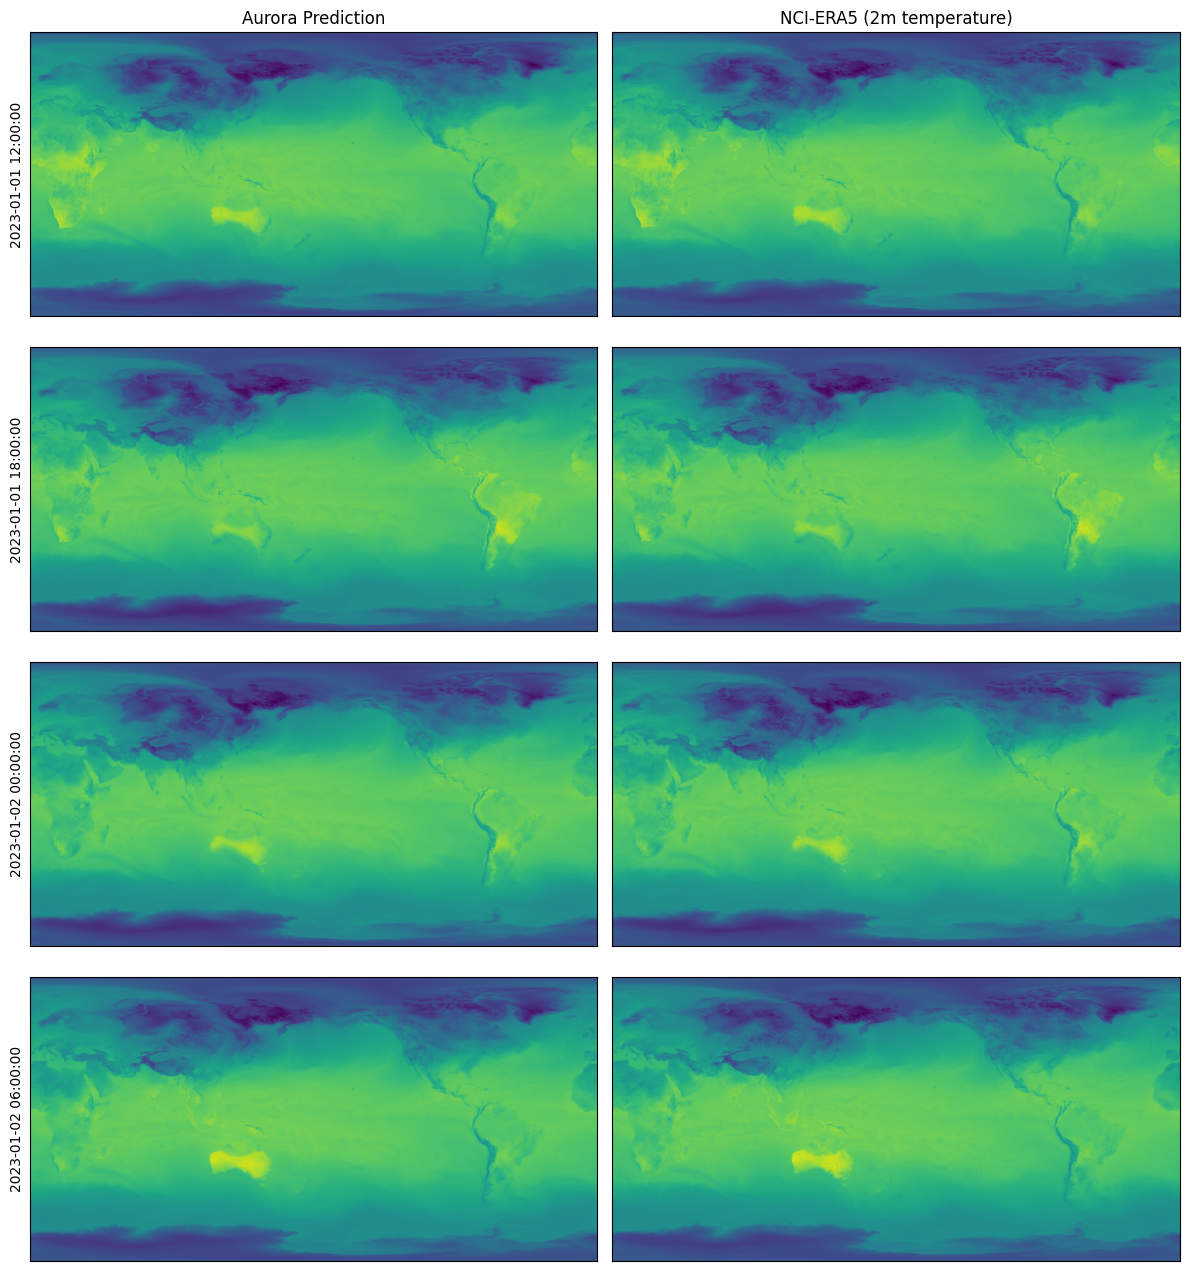

In [3]:
import matplotlib.pyplot as plt

surf_vars_ds, static_vars_ds, atmos_vars_ds  =  nci_era5.get_nci_aurora_ground_truth (preds)

fig, ax = plt.subplots(Pred_Steps, 2, figsize=(12, 6.5/2*Pred_Steps))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["t2m"][i] - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("NCI-ERA5 (2m temperature)")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()

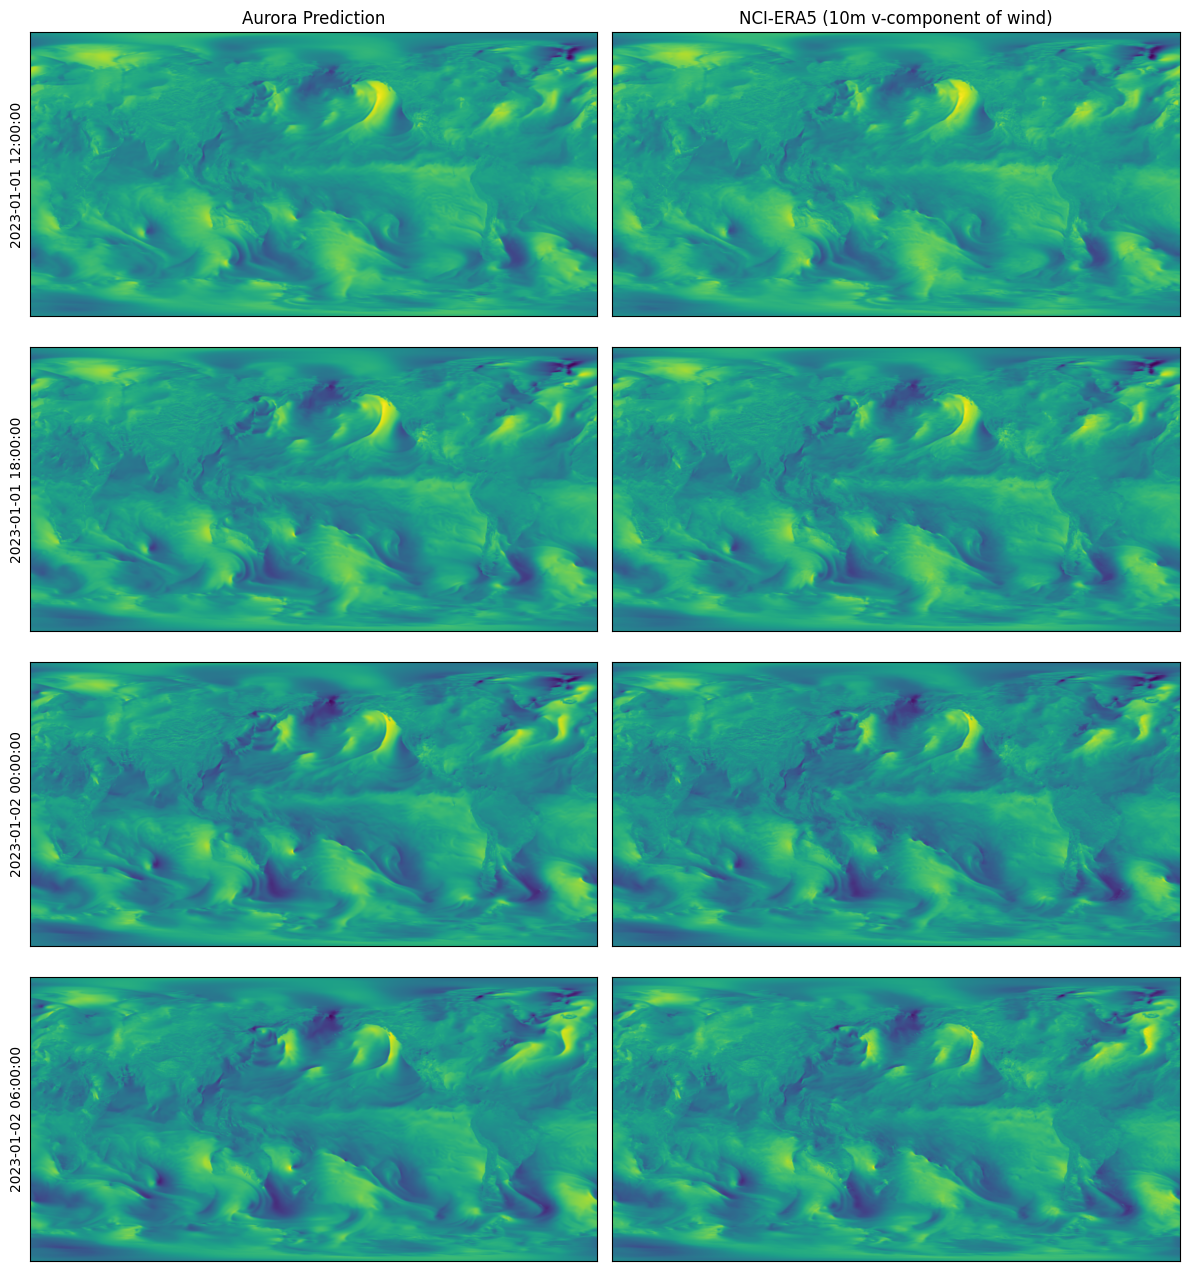

In [4]:
fig, ax = plt.subplots(Pred_Steps, 2, figsize=(12, 6.5/2*Pred_Steps))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["10v"][0, 0].numpy() )
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ax[i, 1].imshow(surf_vars_ds["v10"][i] )
    if i == 0:
        ax[i, 1].set_title("NCI-ERA5 (10m v-component of wind)")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()